# STEP 08 — Evaluation, Stress Tests & Ablation Study

Az RL projekt itt válik valódi mérnöki benchmarkká. A cumulative reward önmagában kevés: a döntést üzleti és energetikai KPI-k alapján kell megítélni, majd meg kell nézni, hogyan viselkedik distribution shift és reward/state változtatás esetén.

In [1]:
from pathlib import Path
import sys, json, math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown, Image

ROOT = Path.cwd()
if ROOT.name == "workflow":
    ROOT = ROOT.parent
SRC = ROOT / "src"
for p in [ROOT, SRC]:
    if str(p) not in sys.path:
        sys.path.insert(0, str(p))

from workflow.shared.utils import ensure_data, load_config, build_env

cfg = load_config()
full, train, val, test = ensure_data()
FIG_DIR = ROOT / "04_results" / "figures"
METRIC_DIR = ROOT / "04_results" / "metrics"
MODEL_DIR = ROOT / "04_results" / "models"
PRED_DIR = ROOT / "04_results" / "predictions"
for p in [FIG_DIR, METRIC_DIR, MODEL_DIR, PRED_DIR]:
    p.mkdir(parents=True, exist_ok=True)

QUICK_MODE = True  # GitHub notebookhoz gyors futás. Komolyabb benchmarkhoz állítsd False-ra.
SEEDS = [42, 123, 2026]
print(f"Project root: {ROOT}")
print(f"Rows: full={len(full):,}, train={len(train):,}, validation={len(val):,}, test={len(test):,}")

Project root: /mnt/data/smart_battery_energy_management_rl
Rows: full=8,760, train=6,132, validation=1,314, test=1,314


## 1. KPI-k és jelentésük

- **Total electricity cost:** közvetlen gazdasági cél.
- **Cost saving %:** No Battery referenciához viszonyított megtakarítás.
- **Peak grid demand:** legnagyobb hálózati import teljesítmény.
- **Peak reduction %:** peak shaving eredmény.
- **Renewable self-consumption:** a lokális renewable mekkora része hasznosul helyben.
- **Battery throughput / cycles:** használati intenzitás, degradáció proxy.
- **Constraint violations:** kért és végrehajtható action eltérések.
- **Average SOC:** policy üzemi tartományának indikátora.
- **Episode return:** a reward objective aggregált értéke.

In [2]:
from battery_rl.agents.baselines import NoBatteryAgent, RuleBasedAgent
from battery_rl.agents.q_learning import TabularQLearningAgent, train_q_learning
from battery_rl.evaluation import evaluate_policy
from workflow.step05_q_learning import make_agent
from battery_rl.data import scenario_transform

low = float(train.electricity_price_eur_per_kwh.quantile(.30))
high = float(train.electricity_price_eur_per_kwh.quantile(.75))
q_path = MODEL_DIR / "q_learning_agent.pkl"
if q_path.exists():
    q_agent = TabularQLearningAgent.load(q_path)
else:
    q_agent = make_agent(cfg, 42)
    train_q_learning(build_env(train, cfg), q_agent, 140 if QUICK_MODE else 600, seed=42)
    q_agent.save(q_path)

## 2. Core policy comparison

Itt közvetlenül újraértékeljük a No Battery, Rule-Based és Q-Learning policykat ugyanazon test distributionön. A DQN/PPO eredményeket a korábbi notebookok által mentett teszt-CSV-kből adjuk hozzá, ha már lefutottak.

In [3]:
rows = []
for name, agent in [("No Battery", NoBatteryAgent()), ("Rule-based", RuleBasedAgent(low, high)), ("Q-Learning", q_agent)]:
    m, _ = evaluate_policy(lambda: build_env(test, cfg, random_start=True), agent, seeds=SEEDS, episodes=8 if QUICK_MODE else 30)
    row = m.mean(numeric_only=True).to_dict(); row["policy"] = name
    row.update({f"{k}_std":v for k,v in m.std(numeric_only=True).to_dict().items()})
    rows.append(row)

for name, filename in [("DQN", "step06_dqn_test_metrics.csv"), ("PPO", "step07_ppo_test_metrics.csv")]:
    p = METRIC_DIR / filename
    if p.exists():
        raw = pd.read_csv(p)
        row = raw.mean(numeric_only=True).to_dict(); row.pop("training_seed", None); row["policy"] = name
        rows.append(row)
comparison = pd.DataFrame(rows)
nb = comparison.loc[comparison.policy == "No Battery"].iloc[0]
comparison["cost_saving_pct"] = 100 * (nb.total_electricity_cost - comparison.total_electricity_cost) / nb.total_electricity_cost
comparison["peak_reduction_pct"] = 100 * (nb.peak_grid_demand_kw - comparison.peak_grid_demand_kw) / nb.peak_grid_demand_kw
display(comparison[["policy","total_electricity_cost","cost_saving_pct","peak_grid_demand_kw","peak_reduction_pct","battery_cycles","constraint_violations"]])

,policy,total_electricity_cost,cost_saving_pct,peak_grid_demand_kw,peak_reduction_pct,battery_cycles,constraint_violations
0,No Battery,104.612954,0.000000,67.194335,0.000000,0.000000,0.000000
1,Rule-based,97.437420,6.859125,73.123718,-8.824232,0.805510,2.250000
2,Q-Learning,106.659006,-1.955831,88.985643,-32.430276,1.433635,5.250000
3,DQN,95.826206,8.399292,65.583327,2.397535,0.326042,1.166667
4,PPO,96.724898,7.540229,63.006269,6.232765,0.200460,14.833333


## 3. Cost saving comparison

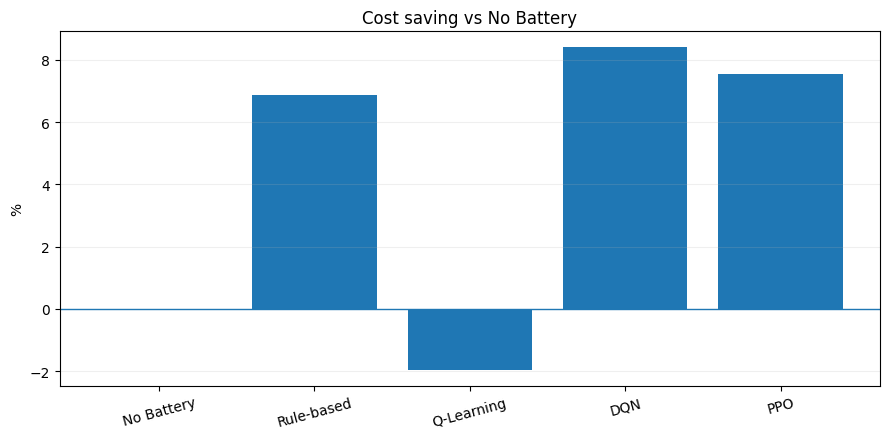

In [4]:
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.bar(comparison.policy, comparison.cost_saving_pct)
ax.axhline(0, linewidth=1)
ax.set_title("Cost saving vs No Battery")
ax.set_ylabel("%"); ax.tick_params(axis="x", rotation=15); ax.grid(axis="y", alpha=0.2)
fig.tight_layout(); fig.savefig(FIG_DIR / "nb08_01_cost_saving.png", dpi=170, bbox_inches="tight")
plt.show()

## 4. Peak reduction comparison

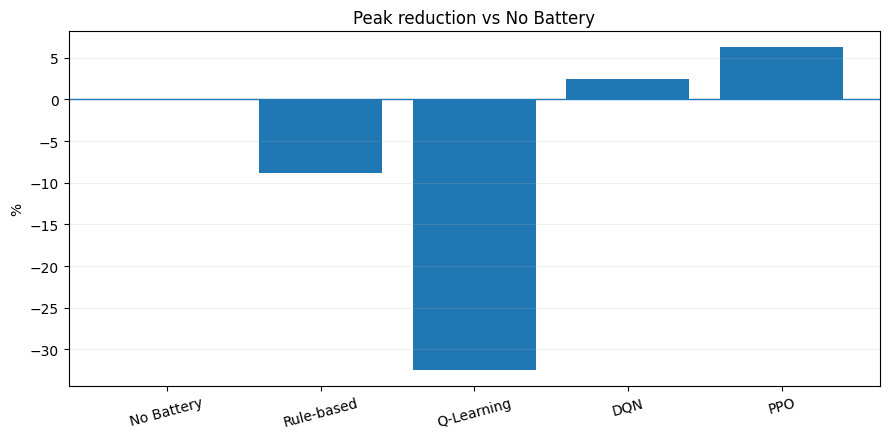

In [5]:
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.bar(comparison.policy, comparison.peak_reduction_pct)
ax.axhline(0, linewidth=1)
ax.set_title("Peak reduction vs No Battery")
ax.set_ylabel("%"); ax.tick_params(axis="x", rotation=15); ax.grid(axis="y", alpha=0.2)
fig.tight_layout(); fig.savefig(FIG_DIR / "nb08_02_peak_reduction.png", dpi=170, bbox_inches="tight")
plt.show()

## 5. Cost vs battery cycles trade-off

Az ideális policy alacsony költséget ér el ésszerű battery usage mellett. Ez a scatter segít felismerni az agresszív, sokat ciklizáló kontrollereket.

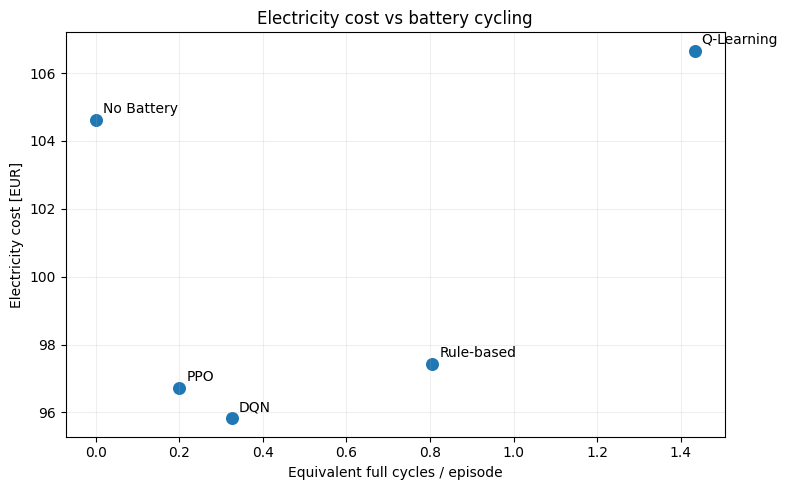

In [6]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(comparison.battery_cycles, comparison.total_electricity_cost, s=70)
for _, r in comparison.iterrows():
    ax.annotate(r.policy, (r.battery_cycles, r.total_electricity_cost), xytext=(5,5), textcoords="offset points")
ax.set_title("Electricity cost vs battery cycling")
ax.set_xlabel("Equivalent full cycles / episode"); ax.set_ylabel("Electricity cost [EUR]"); ax.grid(alpha=0.2)
fig.tight_layout(); fig.savefig(FIG_DIR / "nb08_03_cost_vs_cycles.png", dpi=170, bbox_inches="tight")
plt.show()

## 6. Stress tests — distribution shift

A fix Q-Learning policyt öt szcenárión értékeljük: normal, high price, volatile price, high renewable, low renewable. Itt **nem tanítjuk újra** a policyt — azt mérjük, mennyire generalizál az eltérő működési környezetre.

In [7]:
stress_rows = []
for scenario in ["normal","high_price","volatile_price","high_renewable","low_renewable"]:
    sdf = scenario_transform(test, scenario, seed=2026)
    m, _ = evaluate_policy(lambda sdf=sdf: build_env(sdf, cfg, random_start=True), q_agent, seeds=SEEDS, episodes=6 if QUICK_MODE else 20)
    row = m.mean(numeric_only=True).to_dict(); row["scenario"] = scenario
    stress_rows.append(row)
stress = pd.DataFrame(stress_rows)
display(stress[["scenario","total_electricity_cost","peak_grid_demand_kw","battery_cycles","episode_return"]])

,scenario,total_electricity_cost,peak_grid_demand_kw,battery_cycles,episode_return
0,normal,104.120436,89.912446,1.369846,-108.735995
1,high_price,176.023006,83.800520,1.189583,-180.079514
2,volatile_price,109.723533,88.926168,1.520833,-115.041085
3,high_renewable,80.633681,89.060221,1.330263,-85.089699
4,low_renewable,135.443931,90.764671,1.409430,-140.491318


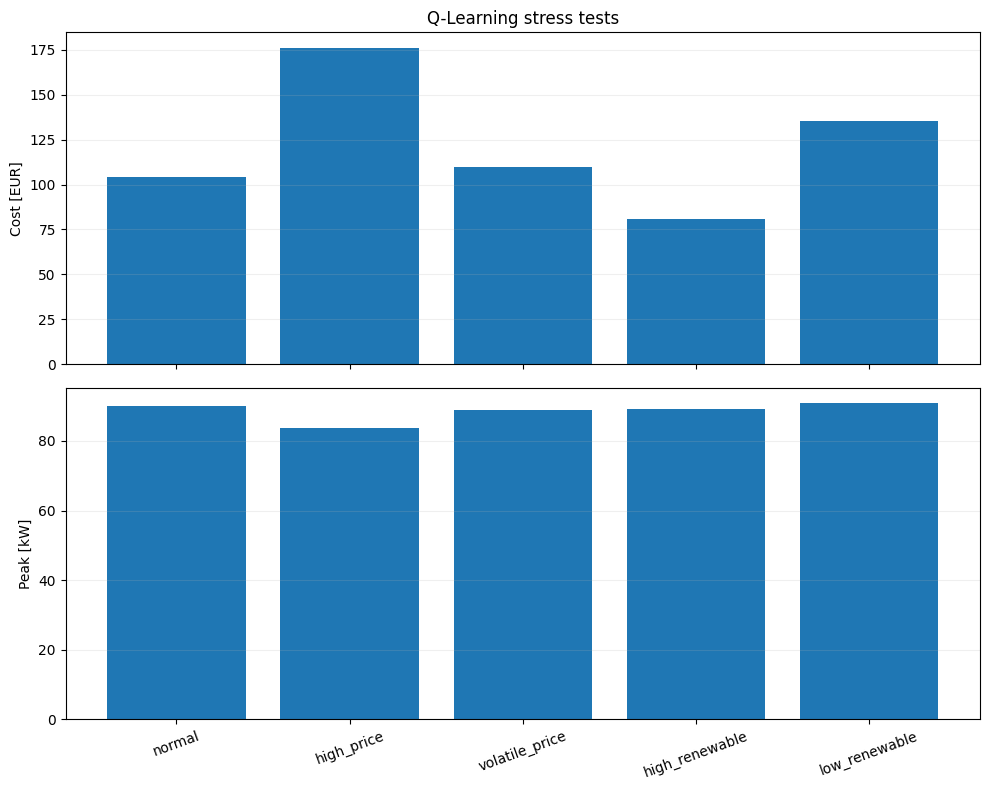

In [8]:
fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True)
axes[0].bar(stress.scenario, stress.total_electricity_cost); axes[0].set_ylabel("Cost [EUR]"); axes[0].set_title("Q-Learning stress tests")
axes[1].bar(stress.scenario, stress.peak_grid_demand_kw); axes[1].set_ylabel("Peak [kW]"); axes[1].tick_params(axis="x", rotation=20)
for ax in axes: ax.grid(axis="y", alpha=0.2)
fig.tight_layout(); fig.savefig(FIG_DIR / "nb08_04_stress_tests.png", dpi=170, bbox_inches="tight")
plt.show()

## 7. Reward ablation — degradation penalty nélkül / azzal

Ez közvetlenül teszteli a reward shapinget. Ha a degradation penaltyt kivesszük, várhatóan az agent kevésbé „fél” a throughputtól. Ha túl nagy a penalty, viszont alulhasználhatja az akkumulátort.

In [9]:
reward_ablation = []
for label, degr in [("without degradation penalty", 0.0), ("with degradation penalty", float(cfg["reward"]["degradation_eur_per_kwh_throughput"]))]:
    a = make_agent(cfg, 123)
    e = build_env(train, cfg, reward_override={"degradation_eur_per_kwh_throughput": degr})
    train_q_learning(e, a, 80 if QUICK_MODE else 300, seed=123)
    m, _ = evaluate_policy(lambda degr=degr: build_env(test, cfg, reward_override={"degradation_eur_per_kwh_throughput": degr}), a, seeds=SEEDS, episodes=6 if QUICK_MODE else 20)
    row = m.mean(numeric_only=True).to_dict(); row["variant"] = label; reward_ablation.append(row)
reward_ablation = pd.DataFrame(reward_ablation)
display(reward_ablation[["variant","total_electricity_cost","battery_throughput_kwh","battery_cycles","episode_return"]])

,variant,total_electricity_cost,battery_throughput_kwh,battery_cycles,episode_return
0,without degradation penalty,100.785625,181.0,0.754167,-103.272875
1,with degradation penalty,100.803636,266.5,1.110417,-104.960390


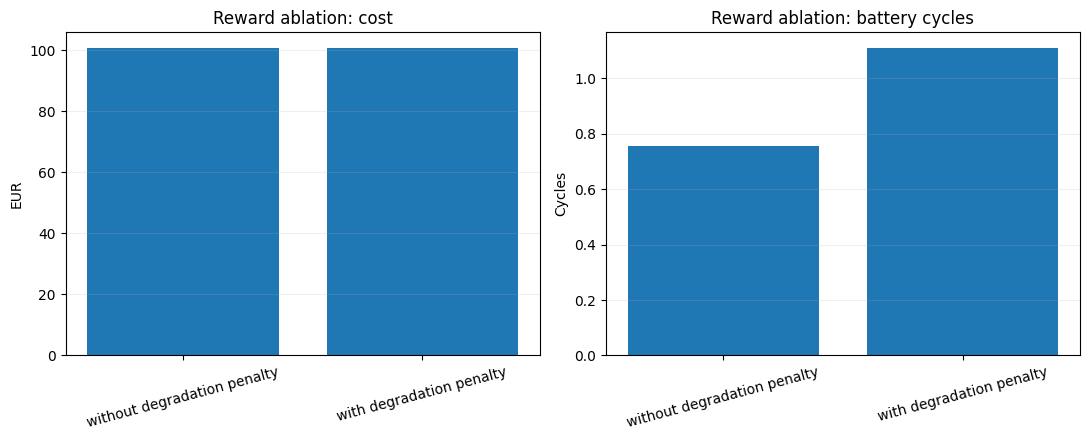

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
axes[0].bar(reward_ablation.variant, reward_ablation.total_electricity_cost); axes[0].set_title("Reward ablation: cost"); axes[0].set_ylabel("EUR")
axes[1].bar(reward_ablation.variant, reward_ablation.battery_cycles); axes[1].set_title("Reward ablation: battery cycles"); axes[1].set_ylabel("Cycles")
for ax in axes: ax.tick_params(axis="x", rotation=15); ax.grid(axis="y", alpha=0.2)
fig.tight_layout(); fig.savefig(FIG_DIR / "nb08_05_reward_ablation.png", dpi=170, bbox_inches="tight")
plt.show()

## 8. State ablation — forecast nélkül / forecasttal

A forecast csak akkor legitim, ha decision-time információ. Itt ugyanazt a tanulási eljárást futtatjuk két state space-szel, és megnézzük, ad-e mérhető értéket a plusz információ.

In [11]:
state_ablation = []
for label, forecast in [("without forecast", False), ("with forecast", True)]:
    a = make_agent(cfg, 2026)
    e = build_env(train, cfg, include_forecast=forecast)
    train_q_learning(e, a, 80 if QUICK_MODE else 300, seed=2026)
    m, _ = evaluate_policy(lambda forecast=forecast: build_env(test, cfg, include_forecast=forecast), a, seeds=SEEDS, episodes=6 if QUICK_MODE else 20)
    row = m.mean(numeric_only=True).to_dict(); row["variant"] = label; state_ablation.append(row)
state_ablation = pd.DataFrame(state_ablation)
display(state_ablation[["variant","total_electricity_cost","peak_grid_demand_kw","battery_cycles","episode_return"]])

,variant,total_electricity_cost,peak_grid_demand_kw,battery_cycles,episode_return
0,without forecast,100.134085,76.973336,0.974013,-103.092939
1,with forecast,99.883865,71.253656,0.813542,-102.436268


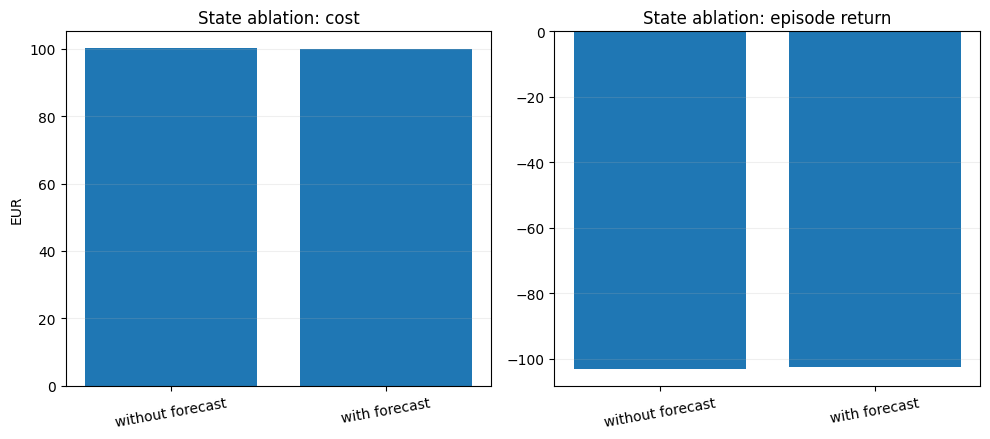

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))
axes[0].bar(state_ablation.variant, state_ablation.total_electricity_cost); axes[0].set_title("State ablation: cost"); axes[0].set_ylabel("EUR")
axes[1].bar(state_ablation.variant, state_ablation.episode_return); axes[1].set_title("State ablation: episode return")
for ax in axes: ax.tick_params(axis="x", rotation=10); ax.grid(axis="y", alpha=0.2)
fig.tight_layout(); fig.savefig(FIG_DIR / "nb08_06_state_ablation.png", dpi=170, bbox_inches="tight")
plt.show()

## 9. Mit jelent egy jó eredmény?

Nem az a cél, hogy minden körülmények között az RL legyen az első. A jó projekt azt mutatja meg, hogy:

1. van reprodukálható baseline;
2. külön test időszakon mérünk;
3. nem csak rewardot, hanem energetikai KPI-kat vizsgálunk;
4. több seed és stress scenario alapján látjuk a bizonytalanságot;
5. reward/state ablationnel bizonyítjuk, hogy mely design decisionök számítanak.